In [ ]:
!pip install pyagrum
!pip install numpy
!pip install causal-learn
!pip install pandas
!pip install pingouin
!pip install bnlearn
!pip install graphviz
!pip install IPython

In [1]:
import sys
import os
sys.path.append(os.getcwd())

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
from FCI import *
import graphviz
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, chisq
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display

C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\bnlearn\__init__.py:22: RuntimeWarning: [bnlearn] Using 'threading' backend instead of 'loky' because Windows + Python 3.13.2 causes joblib/loky crashes.
  warnings.warn(


In [3]:
model = bn.import_DAG("asia")

[bnlearn] >Import <asia>
[bnlearn] >Loading bif file <C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\datazets\data\asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


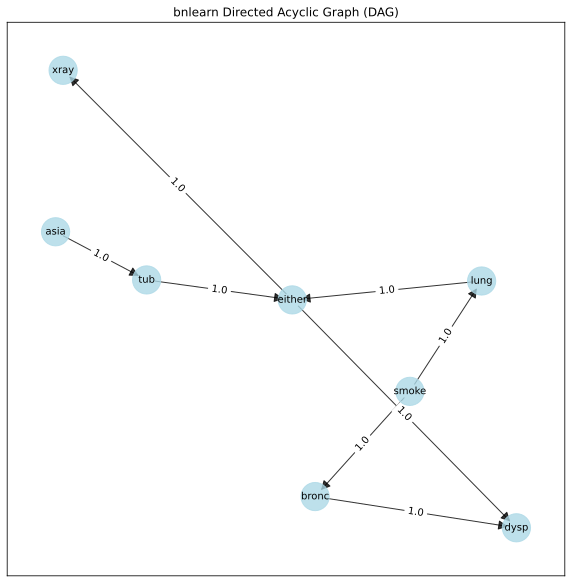

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'asia': array([-0.23133457,  0.359343  ]),
  'tub': array([-0.13955117,  0.16823133]),
  'either': array([0.00724848, 0.08901154]),
  'smoke': array([ 0.12581308, -0.27393286]),
  'lung': array([0.19811399, 0.16401236]),
  'bronc': array([ 0.03026647, -0.69139615]),
  'dysp': array([ 0.23318262, -0.81526921]),
  'xray': array([-0.2237389,  1.       ])},
 'G': <networkx.classes.digraph.DiGraph at 0x2873cf92e40>,
 'node_properties': {'asia': {'node_color': '#ADD8E6', 'node_size': 800},
  'tub': {'node_color': '#ADD8E6', 'node_size': 800},
  'smoke': {'node_color': '#ADD8E6', 'node_size': 800},
  'lung': {'node_color': '#ADD8E6', 'node_size': 800},
  'bronc': {'node_color': '#ADD8E6', 'node_size': 800},
  'either': {'node_color': '#ADD8E6', 'node_size': 800},
  'xray': {'node_color': '#ADD8E6', 'node_size': 800},
  'dysp': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('a

In [4]:
bn.plot(model)

In [5]:
df = bn.sampling(model, n=100000)
df

,asia,tub,smoke,lung,bronc,either,xray,dysp
0,0,1,0,1,0,1,1,0
1,1,1,1,1,1,1,1,1
2,1,1,1,1,0,1,1,0
3,1,1,0,1,0,1,1,1
4,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...
99995,1,1,0,1,0,1,1,0
99996,1,1,1,1,0,1,1,0
99997,1,1,1,1,1,1,1,1
99998,1,1,0,1,0,1,1,1


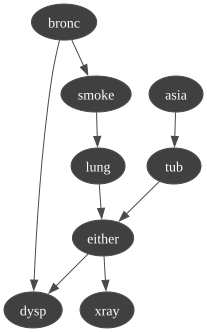

In [6]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

  0%|          | 0/8 [00:00<?, ?it/s]

0 dep 1 | () with p-value 0.000000

0 ind 2 | () with p-value 0.805004

0 ind 3 | () with p-value 0.603558

0 ind 4 | () with p-value 0.429753

0 dep 5 | () with p-value 0.000369

0 dep 6 | () with p-value 0.021193

0 ind 7 | () with p-value 0.298489

1 dep 0 | () with p-value 0.000000

1 ind 2 | () with p-value 0.273421

1 ind 3 | () with p-value 0.908419

1 ind 4 | () with p-value 0.431341

1 dep 5 | () with p-value 0.000000

1 dep 6 | () with p-value 0.000000

1 dep 7 | () with p-value 0.000000

2 ind 0 | () with p-value 0.805004

2 ind 1 | () with p-value 0.273421

2 dep 3 | () with p-value 0.000000

2 dep 4 | () with p-value 0.000000

2 dep 5 | () with p-value 0.000000

2 dep 6 | () with p-value 0.000000

2 dep 7 | () with p-value 0.000000

3 ind 0 | () with p-value 0.603558

3 ind 1 | () with p-value 0.908419

3 dep 2 | () with p-value 0.000000

3 dep 4 | () with p-value 0.000000

3 dep 5 | () with p-value 0.000000

3 dep 6 | () with p-value 0.000000

3 dep 7 | () with p-value 0.

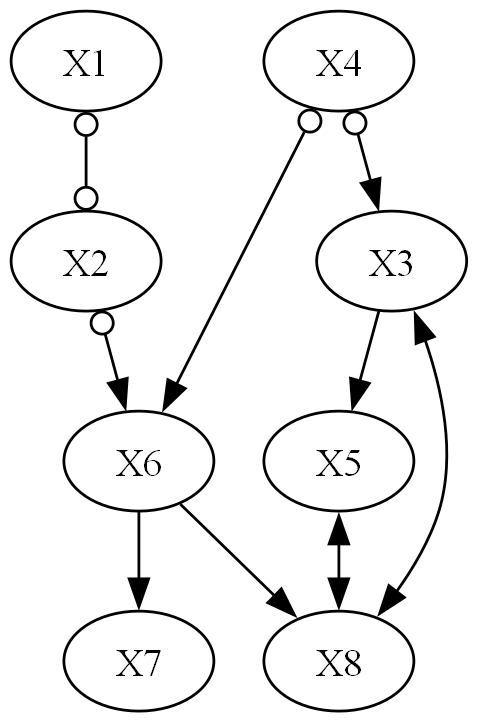

In [7]:
graph, sep_sets = fci(
    df.to_numpy(),
    ci_test=fisherz,
    alpha=0.05,
    verbose=True,
)
node_names = list(df.columns)
pdy = GraphUtils.to_pydot(graph)
display(Image(pdy.create_png()))

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' '>' ' ' ' ' '>']
 [' ' ' ' '>' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' 'o' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' '>' ' ' '>' '-' ' ' ' ']]


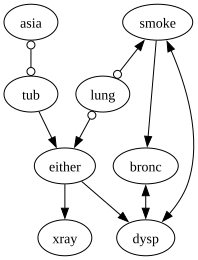

In [8]:
fci_final = run_FCI(df, 0.05, useGum=False)
print(fci_final.matrix)
graph = fci_final.toDot()
graph
# pdag = fci_final.return_PDAG()
# graph = graphviz.Source(pdag.toDot())
# graph

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' '>' ' ' ' ' '>']
 [' ' ' ' '>' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' 'o' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' '>' ' ' '>' '-' ' ' ' ']]


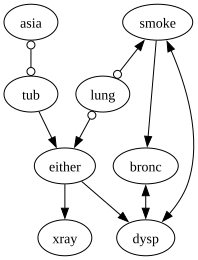

In [9]:
rfci = run_RFCI(df, 0.05, useGum=False)
print(rfci.matrix)
graph = rfci.toDot()
graph
# pdag = rfci.return_PDAG()
# graph = graphviz.Source(pdag.toDot())
# graph